In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
get_ipython().run_line_magic('run', '../_setup.py')

In [ ]:
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

def quantile_score(df, models, q=0.5, id_col="unique_id", target_col="y"):
    df_qs = quantile_loss(df, models, q=q, id_col=id_col, target_col=target_col)
    df_qs.loc[:, df_qs.select_dtypes(include="number").columns] *= 2
    return df_qs

def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")
    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")
    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-\data


### 1. Produce forecasts for the following series using whichever of `Naive()`, `SeasonalNaive()` or `RandomWalkWithDrift()` is more appropriate in each case:

- Australian Population (`global_economy`)
- Bricks (`aus_production`)
- NSW Lambs (`aus_livestock`)
- Household wealth (`hh_budget`).
- Australian takeaway food turnover (`aus_retail`).


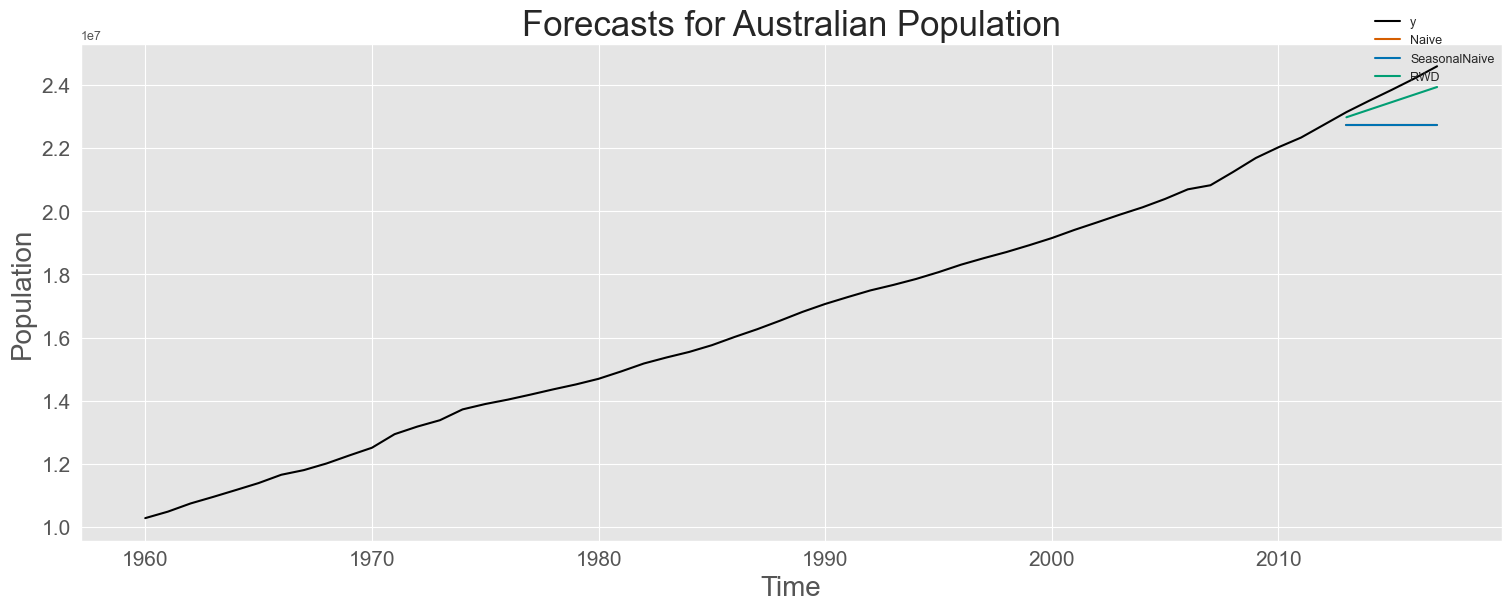

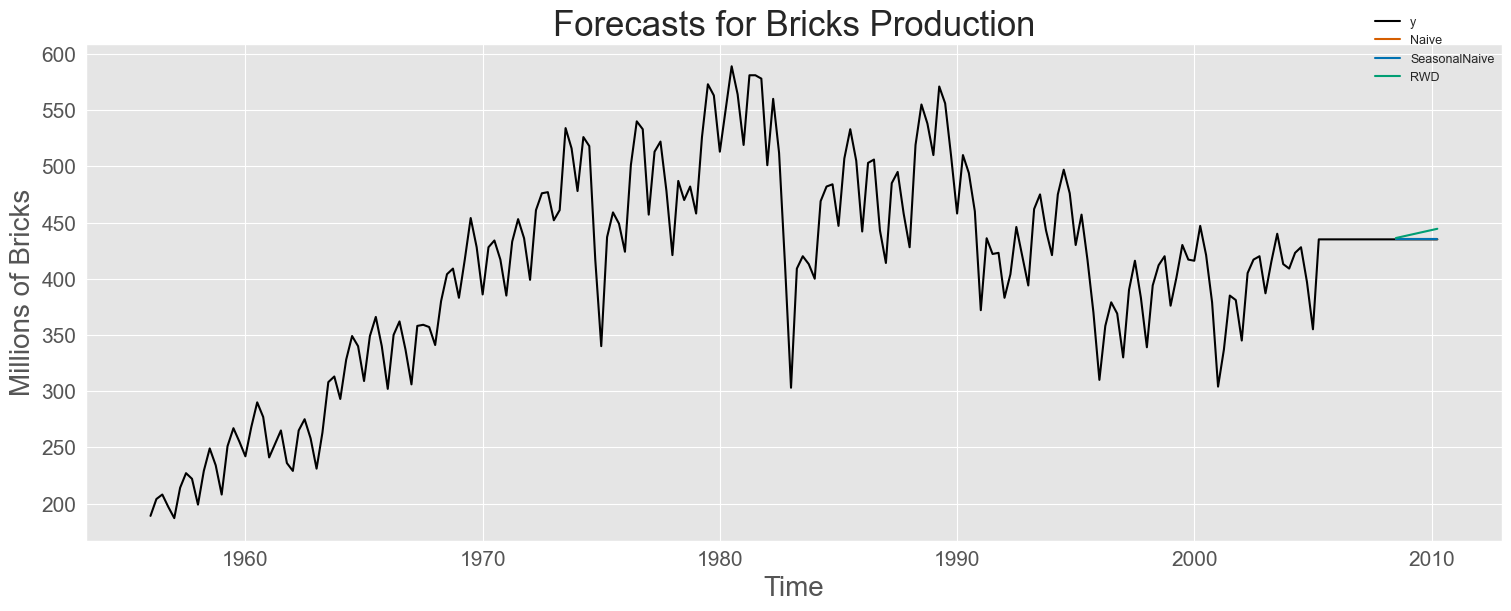

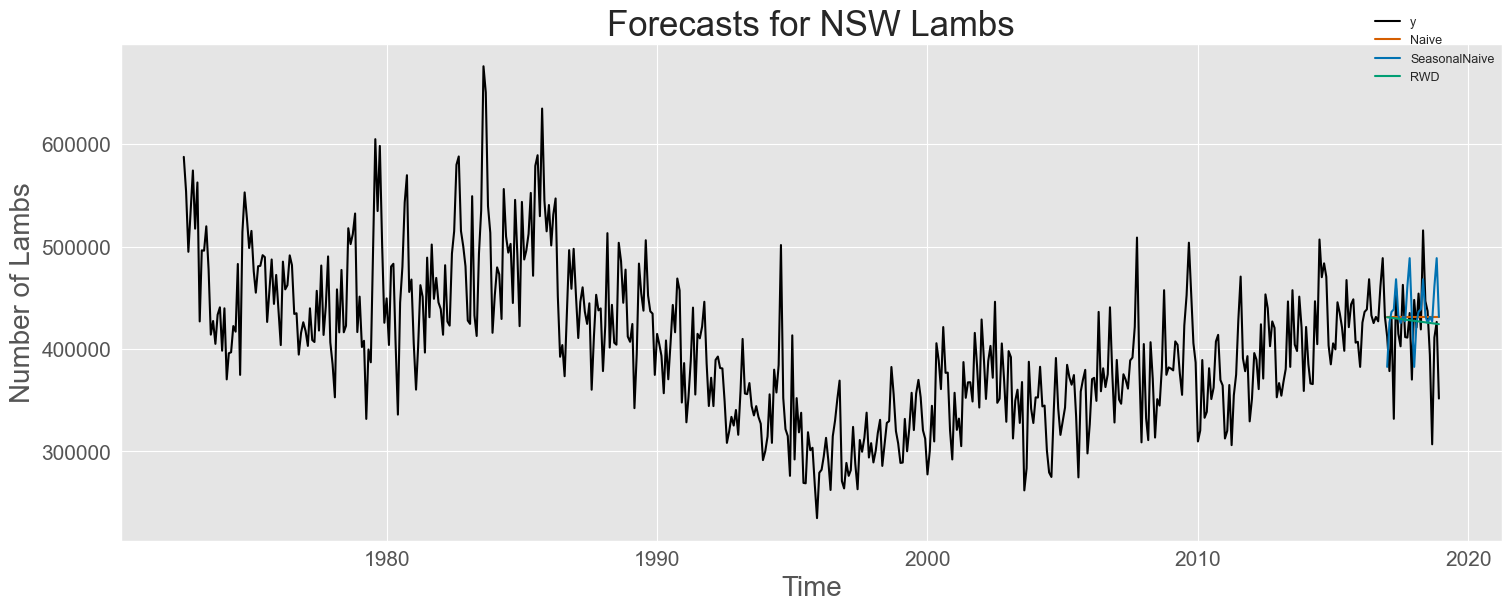

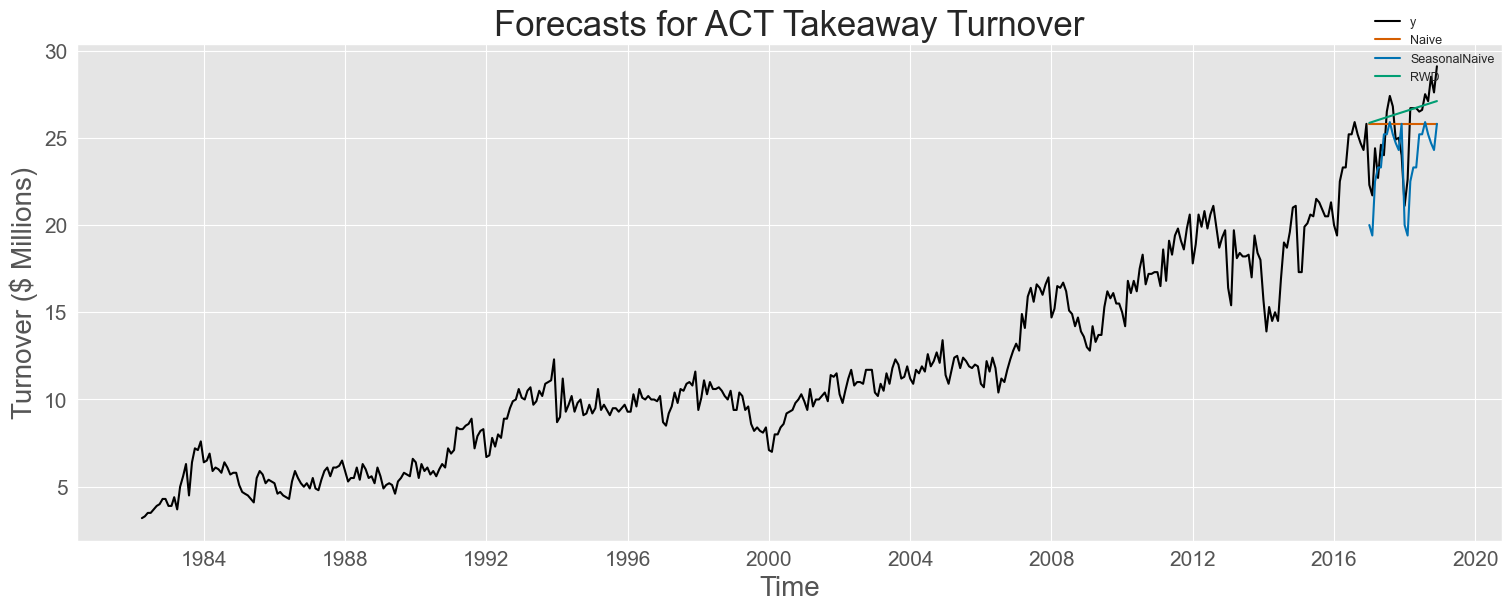

In [4]:
population = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates = ['ds']) # period = 1
    .query("unique_id == 'Australia'")
    .rename(columns = {'Population': 'y'})
    .reset_index()
    [['unique_id', 'ds', 'y']]
)
bricks = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates = ['ds']) # period = 4
    .assign(unique_id = 'Bricks',
            Bricks = lambda x: x['Bricks'].interpolate())
    .rename(columns = {"Bricks": "y"})
    .reset_index()
    [['unique_id', 'ds', 'y']]
)
lambs = (
    pd.read_csv(DATA_DIR / "aus_livestock.csv", parse_dates = ['ds']) # period = 12
    .query("unique_id == 'New South Wales_Lambs'")
    .reset_index()
    [['unique_id', 'ds', 'y']]
)
turnover = (
    pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates = ['Month']) # period = 12
    .query("State == 'Australian Capital Territory' and Industry == 'Takeaway food services'")
    .rename(columns = {"Series ID": "unique_id", "Month": "ds", "Turnover": "y"})
    .reset_index()
    [['unique_id', 'ds', 'y']]
    )

def produce_forecast(df, freq, season_length, h, dataset_name, ylabel):

    test = df.groupby('unique_id').tail(h)
    train = df.drop(test.index)

    naive_method = Naive()
    seasonal_naive_method = SeasonalNaive(season_length=season_length)
    drift_method = RandomWalkWithDrift()

    # Huấn luyện (Sửa lại tham số models)
    sf = StatsForecast(
        freq=freq, 
        models=[naive_method, seasonal_naive_method, drift_method]
    )
    sf.fit(train)
    
    fcasts = sf.predict(h=h).assign(y=test["y"].to_numpy())
    
    fig = plot_series(
        train, fcasts,
        xlabel="Time", 
        ylabel=ylabel,
        title=f"Forecasts for {dataset_name}",
        palette="black_and_3color", 
        rm_legend=False
    )
    
    return fig


datasets_config = [
    {
        "dataset_name": "Australian Population",
        "df": population,
        "freq": "Y",           # Tần suất Năm
        "season_length": 1,    # Chu kỳ 1 (không có tính mùa vụ rõ ràng theo tháng/quý)
        "h": 5,                # Dự báo 5 năm tới
        "ylabel": "Population"
    },
    {
        "dataset_name": "Bricks Production",
        "df": bricks,
        "freq": "Q",           # Tần suất Quý
        "season_length": 4,    # 1 năm có 4 quý
        "h": 8,                # Dự báo 8 quý tới
        "ylabel": "Millions of Bricks"
    },
    {
        "dataset_name": "NSW Lambs",
        "df": lambs,
        "freq": "M",           # Tần suất Tháng
        "season_length": 12,   # 1 năm có 12 tháng
        "h": 24,               # Dự báo 24 tháng tới
        "ylabel": "Number of Lambs"
    },
    {
        "dataset_name": "ACT Takeaway Turnover",
        "df": turnover,
        "freq": "M",           # Tần suất Tháng
        "season_length": 12,   # 1 năm có 12 tháng
        "h": 24,               # Dự báo 24 tháng tới
        "ylabel": "Turnover ($ Millions)"
    }
]

# Chạy tự động qua từng bộ dữ liệu
for config in datasets_config:
    fig = produce_forecast(
        df=config["df"],
        freq=config["freq"],
        season_length=config["season_length"],
        h=config["h"],
        dataset_name=config["dataset_name"],
        ylabel=config["ylabel"]
    )
    display(fig)

- With non-seasonal data, the `Naive` method is fitting with the test data. SO, it's apperently useful for predicting the future line.
- With strong-seasonal data, the `Seasonal Naive` method is pretty good in predicting the seasonality. 
- Besides, the `Drift` method is predicting the data to upward or downward overtime. Don't predict the fitting line for the data.   

### 2. Use the Facebook stock price (dataset `gafa_stock`) to do the following:

- Produce a time plot of the series.
- Produce forecasts using the drift method and plot them.
- Show that the forecasts are identical to extending the line drawn between the first and last observations.
- Try using some of the other benchmark functions to forecast the same data set. Which do you think is best? Why?

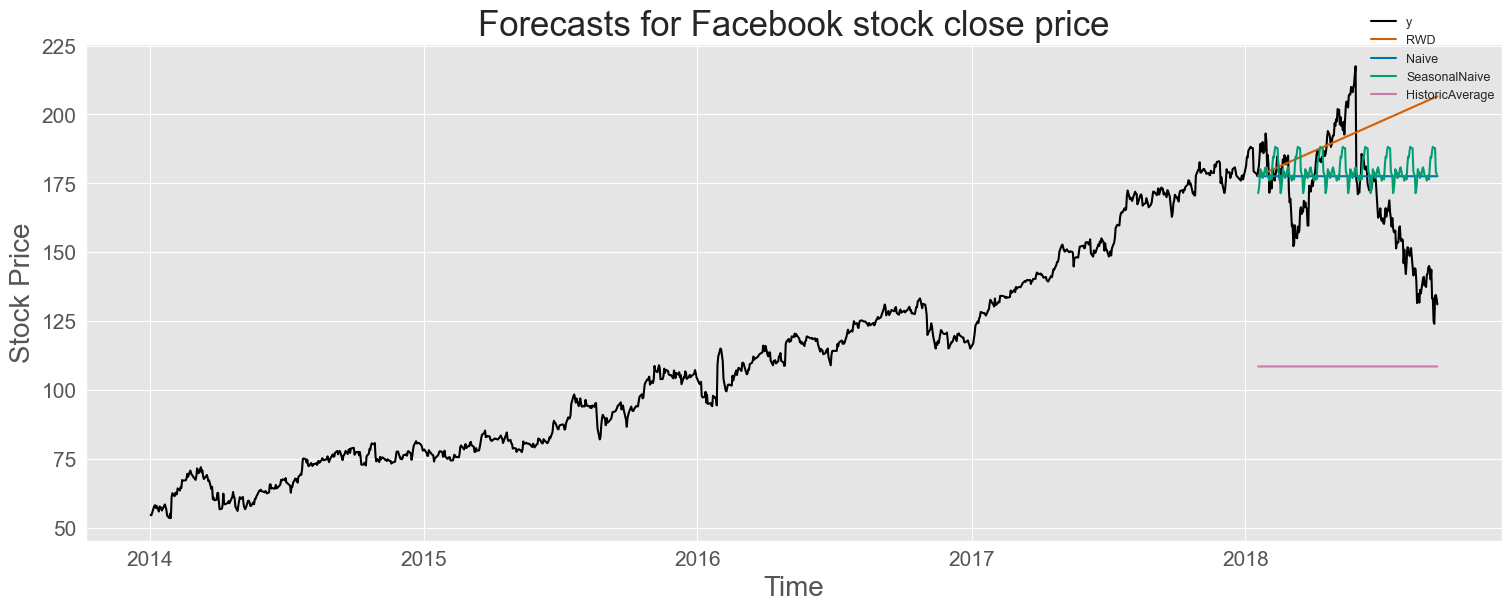

In [5]:
price = (
    pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates = ['ds'])
    .query("unique_id == 'FB_Close'")
    .reset_index()
    [['unique_id', 'ds', 'y']]
)

# plot_series(price, xlabel = 'Time', ylabel = 'Stock Price', title = 'Facebook stock close price over time series') 
h = 240
test = price.groupby('unique_id').tail(h)
train = price.drop(test.index)
drift_method = RandomWalkWithDrift()
naive_method = Naive()
seasonal_naive_method = SeasonalNaive(30)
avg_method = HistoricAverage()
sf = StatsForecast(models = [drift_method, naive_method, seasonal_naive_method, avg_method], freq = 'D')
sf.fit(train)
    
fcasts = sf.predict(h=h).assign(y=test["y"].to_numpy())

fig = plot_series(
    train, fcasts,
    xlabel="Time", 
    ylabel='Stock Price',
    title=f"Forecasts for Facebook stock close price",
    palette="black_and_4color", 
    rm_legend=False
    )
display(fig)

3. Apply a `Seasonal Naïve` method to the quarterly `Australian beer production data` from 1992. Check if the residuals look like white noise, and plot the forecasts. The following code will help.
```
# Extract data of interest
recent_production = aus_production.loc[
    lambda x: (x["ds"].dt.year >= 1992) & (x["unique_id"] == "Beer")
]
# Define and estimate a model
seasonal_naive = SeasonalNaive(4)
sf = StatsForecast(models=[seasonal_naive], freq="Q")
sf.fit(recent_production)
preds = sf.forecast(h=10, df=recent_production, fitted=True)
insample_preds = (
    sf.forecast_fitted_values()
    .assign(resid=lambda x: x["y"] - x["SeasonalNaive"])
)
# Look at the residuals
plot_diagnostics(insample_preds)
# Look a some forecasts
plot_series(recent_production, preds)```

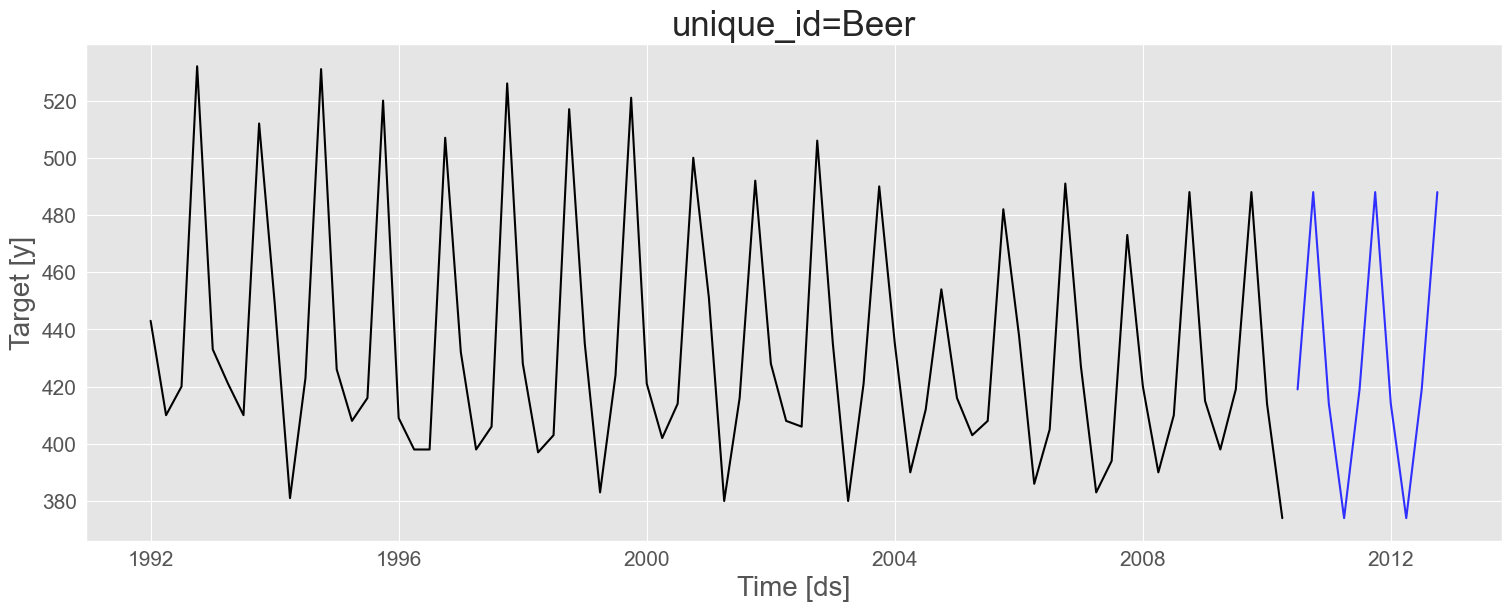

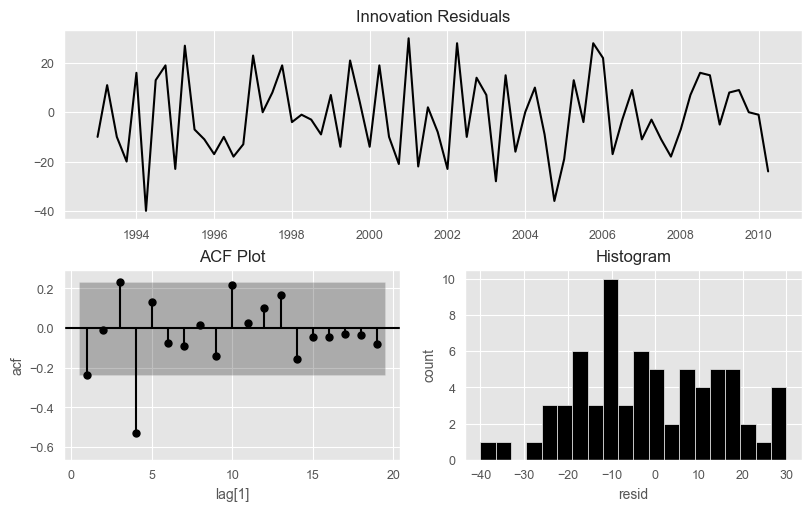

In [ ]:


aus_production = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates = ['ds']) # period = 1
    .assign(unique_id = 'Beer')
    .rename(columns = {'Beer': 'y'})
    .reset_index()
    [['unique_id', 'ds', 'y']]
)

recent_production = aus_production.loc[
    lambda x: (x["ds"].dt.year >= 1992) & (x["unique_id"] == "Beer")
]
# Define and estimate a model
seasonal_naive = SeasonalNaive(4)
sf = StatsForecast(models=[seasonal_naive], freq="Q")
sf.fit(recent_production)
preds = sf.forecast(h=10, df=recent_production, fitted=True)
insample_preds = (
    sf.forecast_fitted_values()
    .assign(resid=lambda x: x["y"] - x["SeasonalNaive"])
)
# Look at the residuals
plot_diagnostics(insample_preds)
# Look a some forecasts
plot_series(recent_production, preds)



### 4. Repeat the previous exercise using the Australian Exports series from `global_economy` and the Bricks series from `aus_production`. Use whichever of `Naive()` or `SeasonalNaive()` is more appropriate in each case.

In [ ]:
exports = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates = ['ds']) # period = 1
    .query("unique_id == 'Australia'")
    .rename(columns = {'Exports': 'y'})
    .reset_index()
    [['unique_id', 'ds', 'y']]
)
bricks = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates = ['ds']) # period = 4
    .assign(unique_id = 'Bricks')
    .rename(columns = {"Bricks": "y"})
    .dropna()
    .reset_index()
    [['unique_id', 'ds', 'y']]
)

datasets_config = [
    {
        "dataset_name": "Australian Exports",
        "df": exports,
        "freq": "Y",           # Tần suất Năm
        "season_length": 1,    # Chu kỳ 1 (không có tính mùa vụ rõ ràng theo tháng/quý)
        "h": 5,                # Dự báo 5 năm tới
        "ylabel": "Exports"
    },
    {
        "dataset_name": "Bricks Production",
        "df": bricks,
        "freq": "Q",           # Tần suất Quý
        "season_length": 4,    # 1 năm có 4 quý
        "h": 8,                # Dự báo 8 quý tới
        "ylabel": "Millions of Bricks"
    }

]

# Chạy tự động qua từng bộ dữ liệu
for config in datasets_config:
    fig = produce_forecast(
        df=config["df"],
        freq=config["freq"],
        season_length=config["season_length"],
        h=config["h"],
        dataset_name=config["dataset_name"],
        ylabel=config["ylabel"]
    )
    display(fig)

### 5. Produce forecasts for the 7 Victorian series in `aus_livestock` using `SeasonalNaive()`. Plot the resulting forecasts including the historical data. Is this a reasonable benchmark for these series?

### 6. Are the following statements true or false? Explain your answer.

- Good forecast methods should have normally distributed residuals.
- A model with small residuals will give good forecasts.
- The best measure of forecast accuracy is MAPE.
- If your model doesn’t forecast well, you should make it more complicated.
- Always choose the model with the best forecast accuracy as measured on the test set.